In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib
from sklearn.isotonic import IsotonicRegression


features = pd.read_csv("../data/customer_features_lowie1.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [93]:
# churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [94]:
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [95]:
X_trainval, X_val, y_trainval, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)
print(f"Train: {len(X_train)}  Cal: {len(X_cal)}  Val: {len(X_val)}")

Train: 69954  Cal: 23318  Val: 23319


# LightGBM

In [96]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "num_leaves": [32, 64, 128],
    "min_child_samples": [20, 30, 50],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_jobs=1),
    param_distributions=lgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_lgb.fit(X_train, y_train)

print("Best params:", search_lgb.best_params_)
print("Best AUC:", search_lgb.best_score_)

lgb_model = search_lgb.best_estimator_
lgb_model.set_params(n_jobs=-1)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 20480, number of negative: 35483
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10948
[LightGBM] [Info] Number of data points in the train set: 55963, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365956 -> initscore=-0.549605
[LightGBM] [Info] Start training from score -0.549605
[LightGBM] [Info] Number of positive: 20480, number of negative: 35483
[LightGBM] [Info] Number of positive: 20480, number of negative: 35483
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025710 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10922
[LightGBM] [Info] Number of data point

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [97]:
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.725075194367792
Log loss: 0.5998506880451273


In [98]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
8,avg_size,1120
46,brand_return_rate,1001
15,revenue_recency_ratio,598
1,max_item_revenue,482
14,frequency_recency_ratio,451
0,total_revenue,417
37,recency_x_frequency,395
20,weighted_orders,376
16,discount_per_item,354
45,recency_x_revenue,337


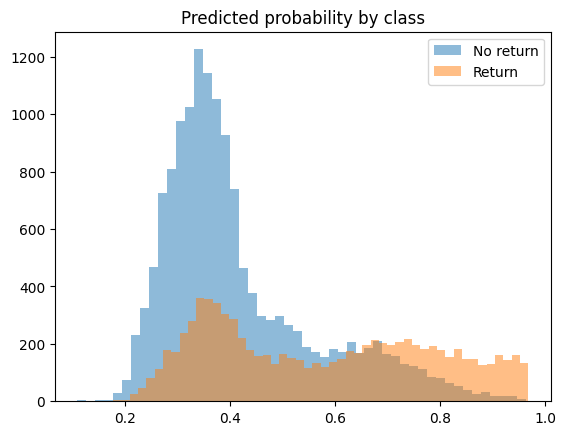

In [99]:
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# XGBoost

In [100]:
xgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric="logloss", n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_xgb.fit(X_train, y_train)

print("Best params:", search_xgb.best_params_)
print("Best AUC:", search_xgb.best_score_)

xgb_model = search_xgb.best_estimator_
xgb_model.set_params(n_jobs=8)
xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_en

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:51:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_en

Best params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.9}
Best AUC: 0.7245052849687552


/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:53:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7252875473293515
XGBoost LogLoss: 0.5999901358660527


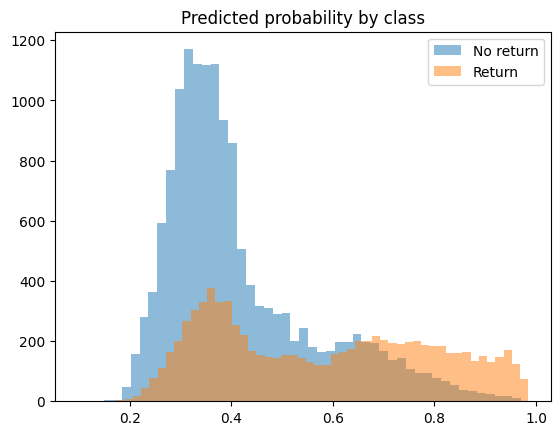

In [101]:
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# CatBoost

In [102]:
cat_param_grid = {
    "iterations": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
    "min_child_samples": [20, 30, 50]
}

search_cat = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, loss_function="Logloss", verbose=False, thread_count=1),
    param_distributions=cat_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_cat.fit(X_train, y_train)

print("Best params:", search_cat.best_params_)
print("Best AUC:", search_cat.best_score_)

best_cat_params = search_cat.best_params_
cat_model = CatBoostClassifier(
    **best_cat_params,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    loss_function="Logloss",
    verbose=False,
    thread_count=-1
)
cat_model.fit(X_train, y_train)

p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

/workspaces/AdvancedAnalyticsTabular/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.8, 'min_child_samples': 20, 'learning_rate': 0.02, 'iterations': 800, 'depth': 6, 'colsample_bylevel': 0.7}
Best AUC: 0.7238437058136633
CatBoost AUC: 0.7255487293964376
CatBoost LogLoss: 0.5996410523656002


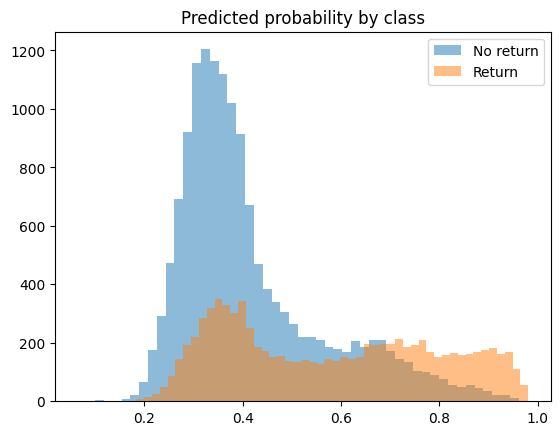

In [103]:
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# Comparison

In [104]:
results = {
    "LightGBM":     roc_auc_score(y_val, p_val_lgb),
    "XGBoost":      roc_auc_score(y_val, p_val_xgb),
    "CatBoost":     roc_auc_score(y_val, p_val_cat),
}
print("Individual model AUCs:")
for name, auc in results.items():
    print(f"  {name}: {auc:.4f}")

p_val_ensemble = (p_val_lgb + p_val_xgb + p_val_cat) / 3
ensemble_auc = roc_auc_score(y_val, p_val_ensemble)
ensemble_ll  = log_loss(y_val, p_val_ensemble)
print(f"\nEnsemble (avg) AUC:      {ensemble_auc:.4f}")
print(f"Ensemble (avg) Log Loss: {ensemble_ll:.4f}")

Individual model AUCs:
  LightGBM: 0.7251
  XGBoost: 0.7253
  CatBoost: 0.7255

Ensemble (avg) AUC:      0.7258
Ensemble (avg) Log Loss: 0.5995


In [105]:
# Kansen op calibratieset
p_cal_lgb = lgb_model.predict_proba(X_cal)[:, 1]
p_cal_xgb = xgb_model.predict_proba(X_cal)[:, 1]
p_cal_cat = cat_model.predict_proba(X_cal)[:, 1]

# Fit calibrators
iso_lgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_lgb, y_cal)
iso_xgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_xgb, y_cal)
iso_cat = IsotonicRegression(out_of_bounds="clip").fit(p_cal_cat, y_cal)

# Gecalibreerde kansen op validatieset
p_val_lgb_cal = iso_lgb.transform(lgb_model.predict_proba(X_val)[:, 1])
p_val_xgb_cal = iso_xgb.transform(xgb_model.predict_proba(X_val)[:, 1])
p_val_cat_cal = iso_cat.transform(cat_model.predict_proba(X_val)[:, 1])
p_val_ensemble_cal = (p_val_lgb_cal + p_val_xgb_cal + p_val_cat_cal) / 3

print(f"Gecalibreerde ensemble AUC: {roc_auc_score(y_val, p_val_ensemble_cal):.4f}")
print(f"Gemiddelde gecalibreerde kans: {p_val_ensemble_cal.mean():.4f}")
print(f"Werkelijke fractie returners: {y_val.mean():.4f}")

Gecalibreerde ensemble AUC: 0.7257
Gemiddelde gecalibreerde kans: 0.3650
Werkelijke fractie returners: 0.3667


In [106]:
# === Extra churn metrics: Brier Score en ECE ===
from sklearn.metrics import brier_score_loss

# Brier Score — voor en na calibratie
brier_raw = brier_score_loss(y_val, p_val_ensemble)
brier_cal = brier_score_loss(y_val, p_val_ensemble_cal)
print(f"Brier Score ongekalibreerd: {brier_raw:.4f}")
print(f"Brier Score gekalibreerd:   {brier_cal:.4f}")
print(f"Verbetering:                {brier_raw - brier_cal:.4f}")

# Log Loss — voor en na calibratie (al beschikbaar maar nu expliciet vergeleken)
from sklearn.metrics import log_loss
ll_raw = log_loss(y_val, p_val_ensemble)
ll_cal = log_loss(y_val, p_val_ensemble_cal)
print(f"\nLog Loss ongekalibreerd: {ll_raw:.4f}")
print(f"Log Loss gekalibreerd:   {ll_cal:.4f}")
print(f"Verbetering:             {ll_raw - ll_cal:.4f}")

# Expected Calibration Error (ECE)
def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            bin_acc  = labels[mask].mean()
            bin_conf = probs[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(labels)

ece_raw = compute_ece(p_val_ensemble.values if hasattr(p_val_ensemble, 'values') 
                      else p_val_ensemble, y_val.values)
ece_cal = compute_ece(p_val_ensemble_cal, y_val.values)

print(f"\nECE ongekalibreerd: {ece_raw:.4f}")
print(f"ECE gekalibreerd:   {ece_cal:.4f}")
print(f"Verbetering:        {ece_raw - ece_cal:.4f}")

print(f"\n--- Samenvatting calibratie-effect ---")
print(f"{'Metric':<25} {'Ongekalibreerd':<18} {'Gekalibreerd':<15} {'Beter?'}")
print(f"{'AUC':<25} {roc_auc_score(y_val, p_val_ensemble):<18.4f} "
      f"{roc_auc_score(y_val, p_val_ensemble_cal):<15.4f} "
      f"{'~gelijk (ranking onveranderd)'}")
print(f"{'Brier Score':<25} {brier_raw:<18.4f} {brier_cal:<15.4f} "
      f"{'✓' if brier_cal < brier_raw else '✗'}")
print(f"{'Log Loss':<25} {ll_raw:<18.4f} {ll_cal:<15.4f} "
      f"{'✓' if ll_cal < ll_raw else '✗'}")
print(f"{'ECE':<25} {ece_raw:<18.4f} {ece_cal:<15.4f} "
      f"{'✓' if ece_cal < ece_raw else '✗'}")

Brier Score ongekalibreerd: 0.2054
Brier Score gekalibreerd:   0.1932
Verbetering:                0.0122

Log Loss ongekalibreerd: 0.5995
Log Loss gekalibreerd:   0.5713
Verbetering:             0.0282

ECE ongekalibreerd: 0.1087
ECE gekalibreerd:   0.0094
Verbetering:        0.0993

--- Samenvatting calibratie-effect ---
Metric                    Ongekalibreerd     Gekalibreerd    Beter?
AUC                       0.7258             0.7257          ~gelijk (ranking onveranderd)
Brier Score               0.2054             0.1932          ✓
Log Loss                  0.5995             0.5713          ✓
ECE                       0.1087             0.0094          ✓


In [107]:
# === Platt Scaling & Temperature Scaling als alternatief voor isotonic ===
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize_scalar

# ─── PLATT SCALING ───────────────────────────────────────────
print("=== Platt Scaling ===")

platt_lgb = LogisticRegression(C=1.0)
platt_xgb = LogisticRegression(C=1.0)
platt_cat = LogisticRegression(C=1.0)

platt_lgb.fit(p_cal_lgb.reshape(-1,1), y_cal)
platt_xgb.fit(p_cal_xgb.reshape(-1,1), y_cal)
platt_cat.fit(p_cal_cat.reshape(-1,1), y_cal)

p_val_lgb_platt = platt_lgb.predict_proba(
    lgb_model.predict_proba(X_val)[:,1].reshape(-1,1))[:,1]
p_val_xgb_platt = platt_xgb.predict_proba(
    xgb_model.predict_proba(X_val)[:,1].reshape(-1,1))[:,1]
p_val_cat_platt = platt_cat.predict_proba(
    cat_model.predict_proba(X_val)[:,1].reshape(-1,1))[:,1]
p_val_ens_platt = (p_val_lgb_platt + p_val_xgb_platt + p_val_cat_platt) / 3

brier_platt = brier_score_loss(y_val, p_val_ens_platt)
ll_platt    = log_loss(y_val, p_val_ens_platt)
ece_platt   = compute_ece(p_val_ens_platt, y_val.values)
auc_platt   = roc_auc_score(y_val, p_val_ens_platt)

print(f"AUC:         {auc_platt:.4f}")
print(f"Brier Score: {brier_platt:.4f}")
print(f"Log Loss:    {ll_platt:.4f}")
print(f"ECE:         {ece_platt:.4f}")
print(f"Gem. kans:   {p_val_ens_platt.mean():.4f}  (werkelijk: {y_val.mean():.4f})")

# ─── TEMPERATURE SCALING ─────────────────────────────────────
print("\n=== Temperature Scaling ===")

def get_logits(probs):
    probs = np.clip(probs, 1e-6, 1 - 1e-6)
    return np.log(probs / (1 - probs))

def temperature_scale(logits, T):
    return 1 / (1 + np.exp(-logits / T))

# Optimaliseer T per model op cal-set via Brier minimalisatie
def find_T(raw_probs_cal, y_cal_vals):
    logits_cal = get_logits(raw_probs_cal)
    def brier_T(T):
        return brier_score_loss(y_cal_vals, temperature_scale(logits_cal, T))
    res = minimize_scalar(brier_T, bounds=(0.1, 10), method='bounded')
    return res.x

T_lgb = find_T(p_cal_lgb, y_cal.values)
T_xgb = find_T(p_cal_xgb, y_cal.values)
T_cat = find_T(p_cal_cat, y_cal.values)

print(f"Optimale temperaturen: LGB={T_lgb:.3f}  XGB={T_xgb:.3f}  CAT={T_cat:.3f}")

p_val_lgb_temp = temperature_scale(
    get_logits(lgb_model.predict_proba(X_val)[:,1]), T_lgb)
p_val_xgb_temp = temperature_scale(
    get_logits(xgb_model.predict_proba(X_val)[:,1]), T_xgb)
p_val_cat_temp = temperature_scale(
    get_logits(cat_model.predict_proba(X_val)[:,1]), T_cat)
p_val_ens_temp = (p_val_lgb_temp + p_val_xgb_temp + p_val_cat_temp) / 3

brier_temp = brier_score_loss(y_val, p_val_ens_temp)
ll_temp    = log_loss(y_val, p_val_ens_temp)
ece_temp   = compute_ece(p_val_ens_temp, y_val.values)
auc_temp   = roc_auc_score(y_val, p_val_ens_temp)

print(f"AUC:         {auc_temp:.4f}")
print(f"Brier Score: {brier_temp:.4f}")
print(f"Log Loss:    {ll_temp:.4f}")
print(f"ECE:         {ece_temp:.4f}")
print(f"Gem. kans:   {p_val_ens_temp.mean():.4f}  (werkelijk: {y_val.mean():.4f})")

# ─── VERGELIJKING ─────────────────────────────────────────────
print("\n=== VERGELIJKING ALLE CALIBRATIEMETHODES ===")
print(f"{'Methode':<22} {'AUC':<8} {'Brier':<8} {'LogLoss':<10} {'ECE':<8} {'Gem.kans'}")
print("-" * 70)
for naam, auc, brier, ll, ece, gem in [
    ("Ongekalibreerd",   roc_auc_score(y_val, p_val_ensemble), brier_raw, ll_raw, ece_raw, p_val_ensemble.mean()),
    ("Isotonic",         roc_auc_score(y_val, p_val_ensemble_cal),  brier_cal, ll_cal, ece_cal, p_val_ensemble_cal.mean()),
    ("Platt Scaling",    auc_platt, brier_platt, ll_platt, ece_platt, p_val_ens_platt.mean()),
    ("Temperature",      auc_temp,  brier_temp,  ll_temp,  ece_temp,  p_val_ens_temp.mean()),
]:
    print(f"{naam:<22} {auc:<8.4f} {brier:<8.4f} {ll:<10.4f} {ece:<8.4f} {gem:.4f}")

print(f"\nWerkelijke fractie returners: {y_val.mean():.4f}")

=== Platt Scaling ===


AUC:         0.7258
Brier Score: 0.1937
Log Loss:    0.5729
ECE:         0.0159
Gem. kans:   0.3653  (werkelijk: 0.3667)

=== Temperature Scaling ===
Optimale temperaturen: LGB=0.816  XGB=0.827  CAT=0.825
AUC:         0.7258
Brier Score: 0.2046
Log Loss:    0.5991
ECE:         0.1007
Gem. kans:   0.4675  (werkelijk: 0.3667)

=== VERGELIJKING ALLE CALIBRATIEMETHODES ===
Methode                AUC      Brier    LogLoss    ECE      Gem.kans
----------------------------------------------------------------------
Ongekalibreerd         0.7258   0.2054   0.5995     0.1087   0.4754
Isotonic               0.7257   0.1932   0.5713     0.0094   0.3650
Platt Scaling          0.7258   0.1937   0.5729     0.0159   0.3653
Temperature            0.7258   0.2046   0.5991     0.1007   0.4675

Werkelijke fractie returners: 0.3667


# Save Models

In [108]:
import os
os.makedirs("../models", exist_ok=True)


In [109]:
feature_cols = X.columns.tolist()

In [110]:
joblib.dump(lgb_model, "../models/lowie1_churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/lowie1_churn_xgb_model.pkl")
joblib.dump(cat_model, "../models/lowie1_churn_cat_model.pkl")
joblib.dump(feature_cols, "../models/lowie1_feature_columns.pkl")

joblib.dump(iso_lgb, "../models/lowie1_iso_lgb.pkl")
joblib.dump(iso_xgb, "../models/lowie1_iso_xgb.pkl")
joblib.dump(iso_cat, "../models/lowie1_iso_cat.pkl")

['../models/lowie1_iso_cat.pkl']